In [28]:
# ====================================================
# ПРОЕКТ: PROCESS MINING
# ====================================================

# Шаг 1: Установка библиотек
!pip install pm4py --quiet
!pip install graphviz --quiet

import pandas as pd
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from collections import Counter

print("✅ Все библиотеки установлены")

✅ Все библиотеки установлены


In [29]:
# ====================================================
# ШАГ 2: СОЗДАНИЕ ДАННЫХ
# ====================================================

np.random.seed(42)

data = {
    'case_id': [],
    'activity': [],
    'timestamp': []
}

start_date = dt.datetime(2024, 1, 1)

for case_id in range(1, 51):
    if case_id <= 30:
        activities = ['Register request', 'Check documents', 'Approve']
    elif case_id <= 40:
        activities = ['Register request', 'Check documents', 'Reject', 'Rework', 'Approve']
    else:
        activities = ['Register request', 'Check documents', 'Reject']

    current_time = start_date + dt.timedelta(days=case_id)
    for i, act in enumerate(activities):
        data['case_id'].append(case_id)
        data['activity'].append(act)
        data['timestamp'].append(current_time + dt.timedelta(hours=i*24))

df = pd.DataFrame(data)

print(f"✅ Создано {len(df)} событий")
print(f"✅ Кейсов: {df['case_id'].nunique()}")
print(f"✅ Активностей: {df['activity'].unique().tolist()}")

✅ Создано 170 событий
✅ Кейсов: 50
✅ Активностей: ['Register request', 'Check documents', 'Approve', 'Reject', 'Rework']


In [30]:
# ====================================================
# ШАГ 3: ПРЕОБРАЗОВАНИЕ В EVENT LOG
# ====================================================

import pm4py

df['case_id'] = df['case_id'].astype(str)
df['activity'] = df['activity'].astype(str)
df['timestamp'] = pd.to_datetime(df['timestamp'])

event_log = pm4py.format_dataframe(
    df,
    case_id='case_id',
    activity_key='activity',
    timestamp_key='timestamp'
)

print(f"✅ Event log создан")
print(f"   Кейсов: {event_log['case:concept:name'].nunique()}")
print(f"   Событий: {len(event_log)}")

✅ Event log создан
   Кейсов: 50
   Событий: 170


In [31]:
# ====================================================
# ШАГ 4: ПОСТРОЕНИЕ DFG (ГРАФ ПЕРЕХОДОВ)
# ====================================================

dfg, start_activities, end_activities = pm4py.discover_dfg(event_log)

print(f"✅ Найдено переходов: {len(dfg)}")
print(f"\nСтартовые активности: {list(start_activities.keys())}")
print(f"Финальные активности: {list(end_activities.keys())}")

print("\nТОП-10 ПЕРЕХОДОВ:")
sorted_dfg = sorted(dfg.items(), key=lambda x: x[1], reverse=True)[:10]
for (from_act, to_act), count in sorted_dfg:
    print(f"  {from_act} → {to_act}: {count} раз")

✅ Найдено переходов: 5

Стартовые активности: ['Register request']
Финальные активности: ['Approve', 'Reject']

ТОП-10 ПЕРЕХОДОВ:
  Register request → Check documents: 50 раз
  Check documents → Approve: 30 раз
  Check documents → Reject: 20 раз
  Reject → Rework: 10 раз
  Rework → Approve: 10 раз


In [32]:
# ====================================================
# ШАГ 5: АНАЛИЗ ВАРИАНТОВ ПРОЦЕССА
# ====================================================

variants = {}
for case_id, group in event_log.groupby('case:concept:name'):
    variant = tuple(group['concept:name'].tolist())
    if variant not in variants:
        variants[variant] = []
    variants[variant].append(case_id)

sorted_variants = sorted(variants.items(), key=lambda x: len(x[1]), reverse=True)

print(f"✅ Всего вариантов: {len(variants)}")
print("\nТОП-5 ВАРИАНТОВ:")
for i, (variant, cases) in enumerate(sorted_variants[:5]):
    pct = len(cases) / event_log['case:concept:name'].nunique() * 100
    print(f"\n{i+1}. {len(cases)} кейсов ({pct:.1f}%):")
    print(f"   {' → '.join(variant)}")

✅ Всего вариантов: 3

ТОП-5 ВАРИАНТОВ:

1. 30 кейсов (60.0%):
   Register request → Check documents → Approve

2. 10 кейсов (20.0%):
   Register request → Check documents → Reject → Rework → Approve

3. 10 кейсов (20.0%):
   Register request → Check documents → Reject


In [33]:
# ====================================================
# ШАГ 6: ВРЕМЕННЫЕ МЕТРИКИ
# ====================================================

durations = {}
for case_id, group in event_log.groupby('case:concept:name'):
    start_time = group['time:timestamp'].min()
    end_time = group['time:timestamp'].max()
    duration_hours = (end_time - start_time).total_seconds() / 3600
    durations[case_id] = duration_hours

avg_duration = sum(durations.values()) / len(durations)
min_duration = min(durations.values())
max_duration = max(durations.values())

print(f"✅ Временные метрики:")
print(f"   Средняя длительность: {avg_duration:.1f} ч ({avg_duration/24:.1f} дн.)")
print(f"   Минимальная: {min_duration:.1f} ч")
print(f"   Максимальная: {max_duration:.1f} ч")

# Результативность
success_cases = [c for c, g in event_log.groupby('case:concept:name')
                 if g.iloc[-1]['concept:name'] == 'Approve']
fail_cases = [c for c, g in event_log.groupby('case:concept:name')
              if g.iloc[-1]['concept:name'] == 'Reject']

print(f"\n   Успешных (Approve): {len(success_cases)} ({len(success_cases)/len(durations)*100:.1f}%)")
print(f"   Отказов (Reject): {len(fail_cases)} ({len(fail_cases)/len(durations)*100:.1f}%)")

✅ Временные метрики:
   Средняя длительность: 57.6 ч (2.4 дн.)
   Минимальная: 48.0 ч
   Максимальная: 96.0 ч

   Успешных (Approve): 40 (80.0%)
   Отказов (Reject): 10 (20.0%)


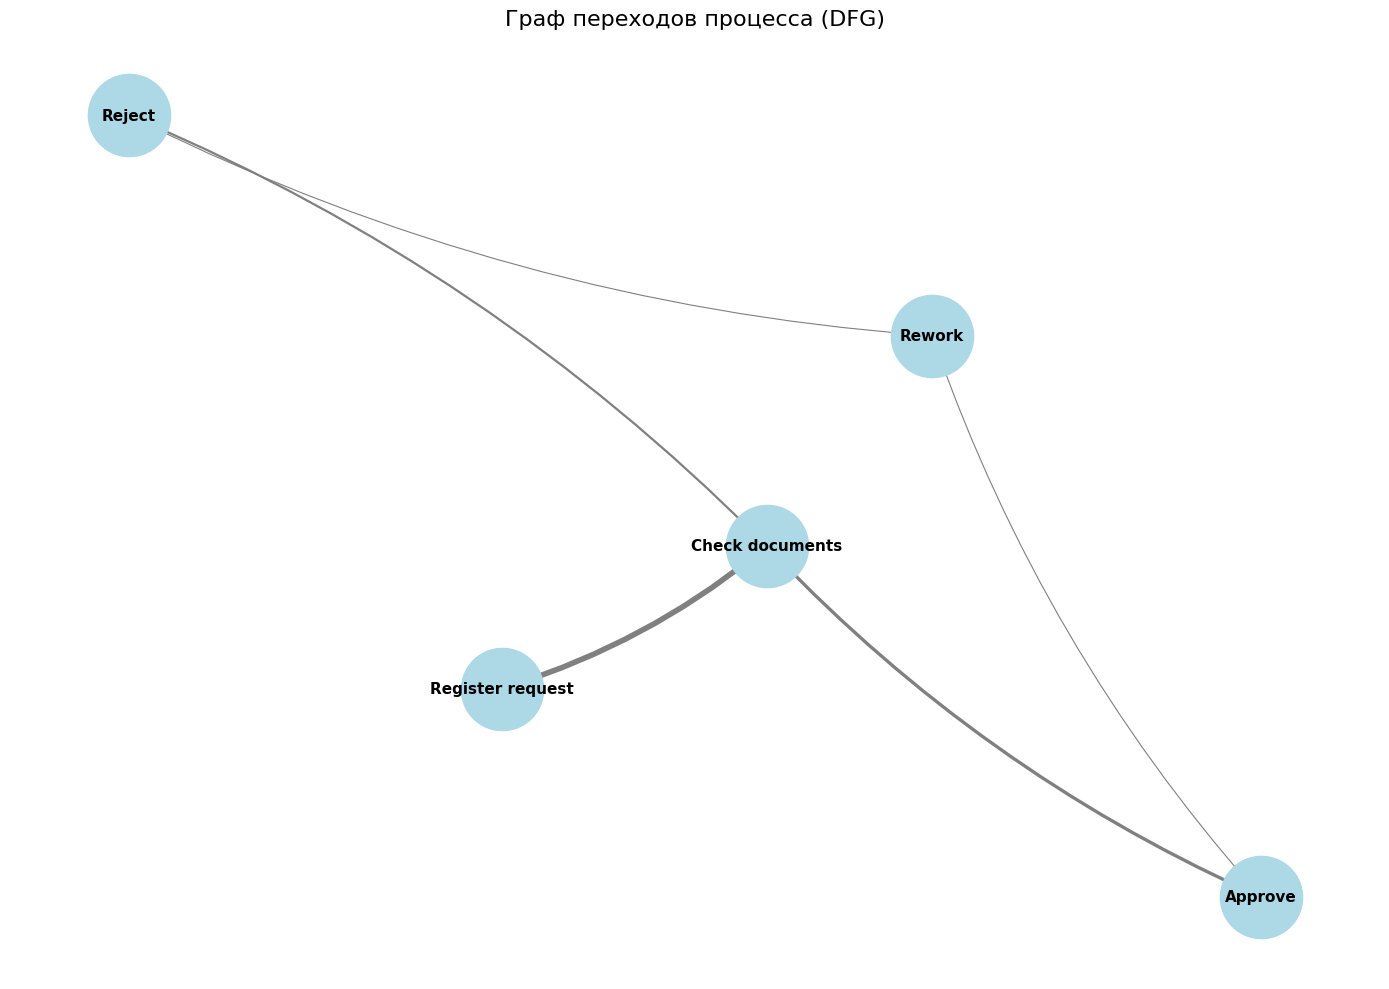

In [34]:
# ====================================================
# ШАГ 7: ВИЗУАЛИЗАЦИЯ 1 - ГРАФ ПЕРЕХОДОВ (networkx)
# ====================================================

G = nx.DiGraph()

all_activities = set()
for (from_act, to_act), count in dfg.items():
    all_activities.add(from_act)
    all_activities.add(to_act)

for act in all_activities:
    G.add_node(act)

for (from_act, to_act), count in dfg.items():
    G.add_edge(from_act, to_act, weight=count)

plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, k=2, seed=42, iterations=50)

nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=3500)
nx.draw_networkx_labels(G, pos, font_size=11, font_weight='bold')

edges = G.edges()
weights = [G[u][v]['weight'] for u, v in edges]
max_weight = max(weights) if weights else 1
nx.draw_networkx_edges(G, pos, width=[w/max_weight*4 for w in weights],
                       edge_color='gray', arrows=True, arrowsize=20,
                       connectionstyle="arc3,rad=0.1")

plt.title('Граф переходов процесса (DFG)', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

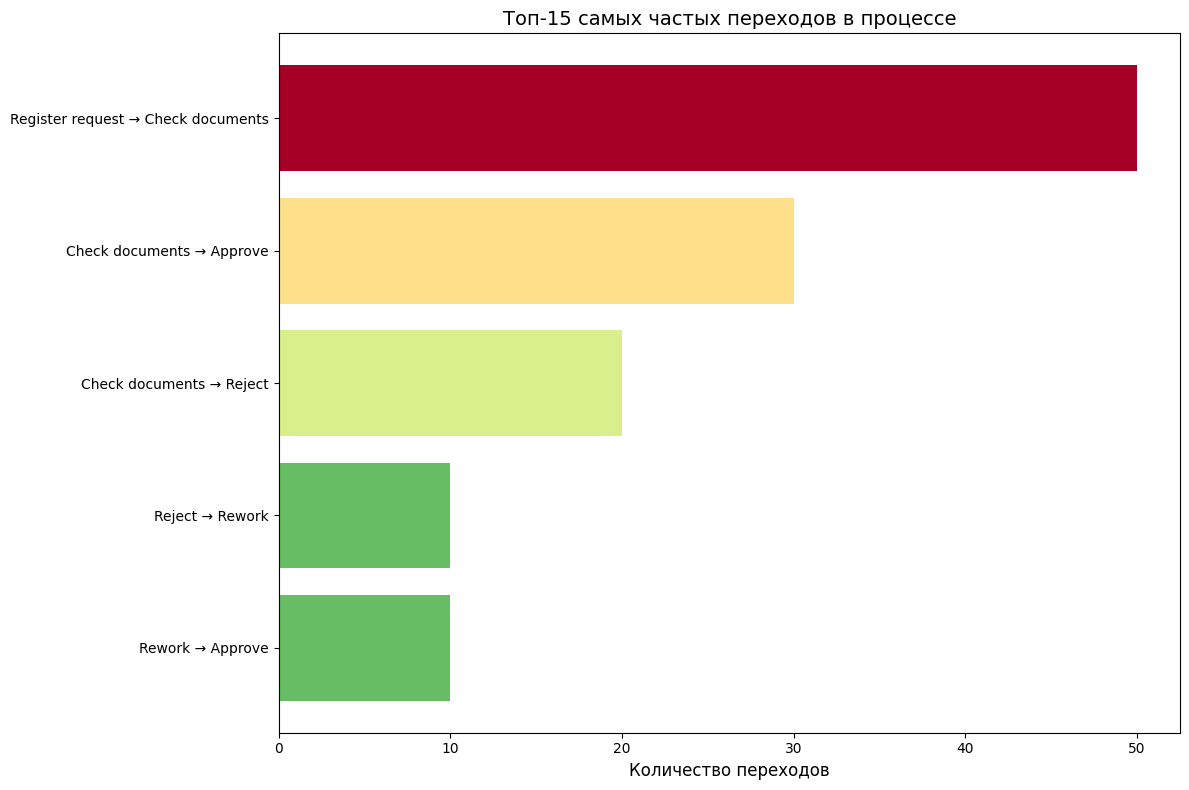

In [35]:
# ====================================================
# ШАГ 8: ВИЗУАЛИЗАЦИЯ 2 - ТОП ПЕРЕХОДОВ
# ====================================================

top_transitions = sorted(dfg.items(), key=lambda x: x[1], reverse=True)[:15]
transitions_names = [f"{f} → {t}" for (f, t), _ in top_transitions]
transitions_counts = [c for _, c in top_transitions]

plt.figure(figsize=(12, 8))
colors = plt.cm.RdYlGn_r([c/max(transitions_counts) for c in transitions_counts])
plt.barh(transitions_names, transitions_counts, color=colors)
plt.xlabel('Количество переходов', fontsize=12)
plt.title('Топ-15 самых частых переходов в процессе', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

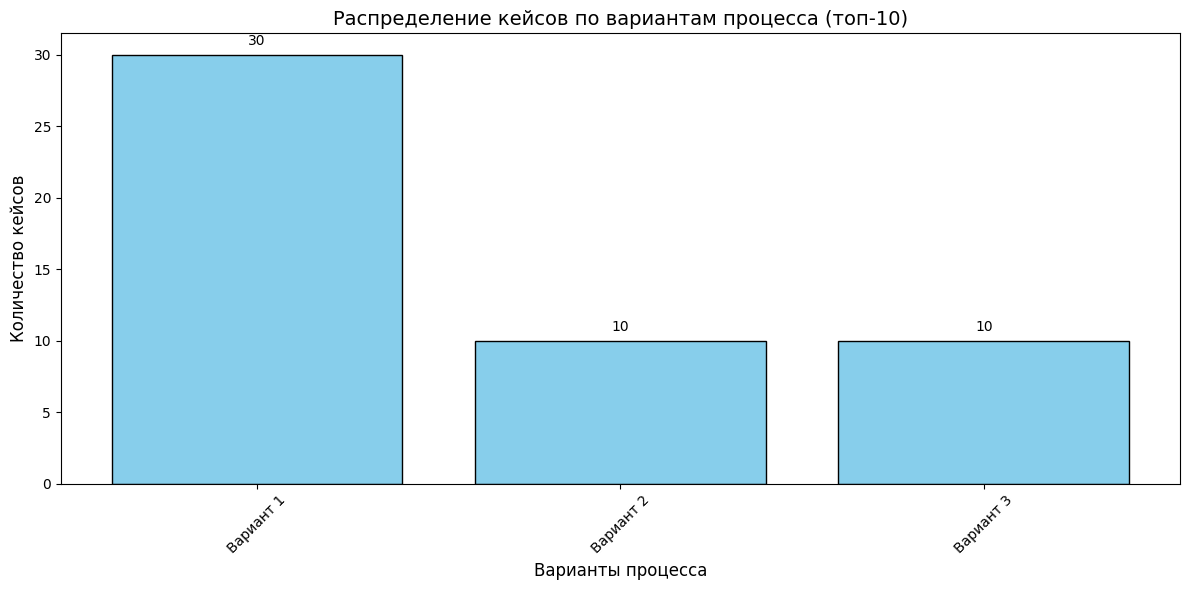

In [36]:
# ====================================================
# ШАГ 9: ВИЗУАЛИЗАЦИЯ 3 - РАСПРЕДЕЛЕНИЕ ВАРИАНТОВ
# ====================================================

variant_counts = [len(cases) for _, cases in sorted_variants[:10]]
variant_names = [f"Вариант {i+1}" for i in range(len(variant_counts))]

plt.figure(figsize=(12, 6))
bars = plt.bar(variant_names, variant_counts, color='skyblue', edgecolor='black')
plt.xlabel('Варианты процесса', fontsize=12)
plt.ylabel('Количество кейсов', fontsize=12)
plt.title('Распределение кейсов по вариантам процесса (топ-10)', fontsize=14)

for bar, count in zip(bars, variant_counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(count), ha='center', va='bottom')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

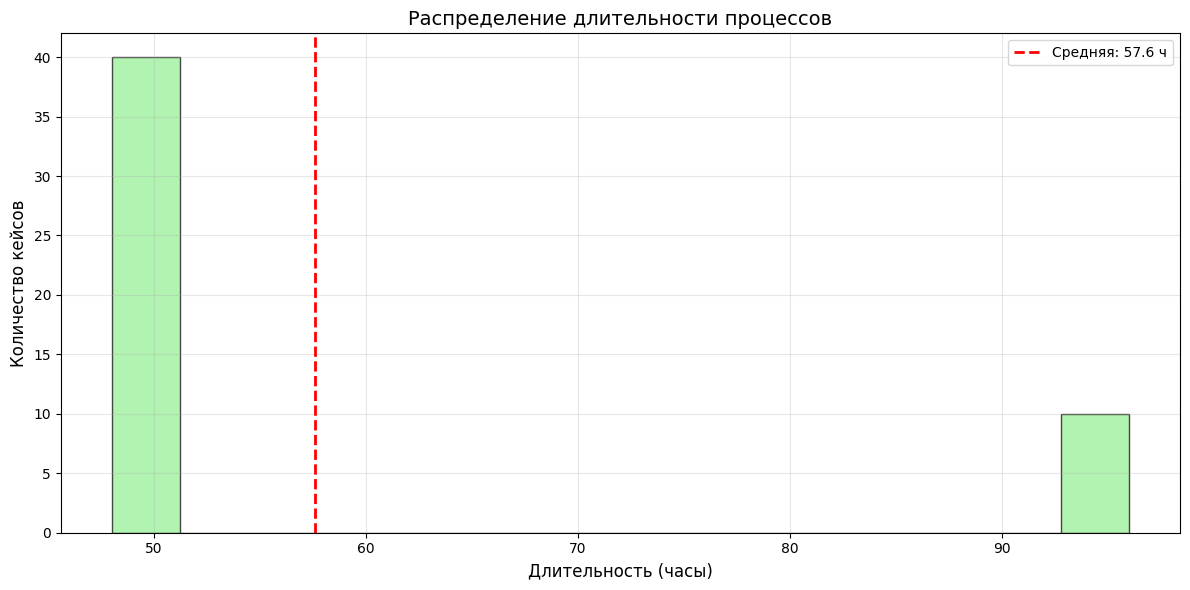

In [37]:
# ====================================================
# ШАГ 10: ВИЗУАЛИЗАЦИЯ 4 - ГИСТОГРАММА ДЛИТЕЛЬНОСТИ
# ====================================================

durations_list = list(durations.values())

plt.figure(figsize=(12, 6))
plt.hist(durations_list, bins=15, color='lightgreen', edgecolor='black', alpha=0.7)
plt.axvline(avg_duration, color='red', linestyle='--', linewidth=2,
            label=f'Средняя: {avg_duration:.1f} ч')
plt.xlabel('Длительность (часы)', fontsize=12)
plt.ylabel('Количество кейсов', fontsize=12)
plt.title('Распределение длительности процессов', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

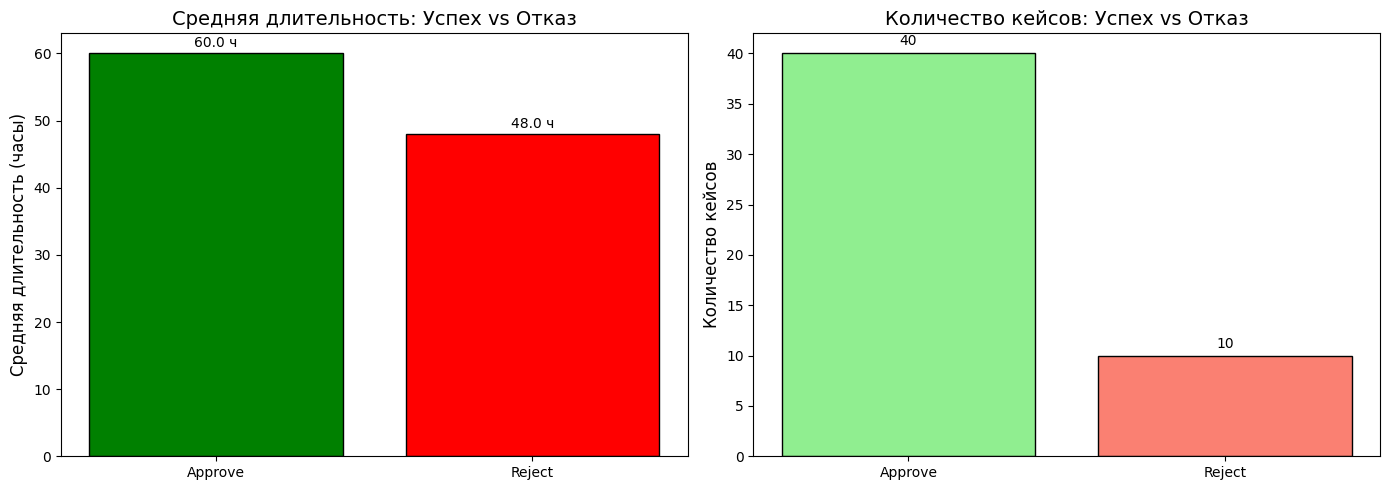

In [38]:
# ====================================================
# ШАГ 11: ВИЗУАЛИЗАЦИЯ 5 - УСПЕХ VS ОТКАЗ
# ====================================================

results_data = []
for case_id, group in event_log.groupby('case:concept:name'):
    last_activity = group.iloc[-1]['concept:name']
    duration = durations[case_id]
    results_data.append({'result': last_activity, 'duration': duration})

results_df = pd.DataFrame(results_data)
result_stats = results_df.groupby('result')['duration'].agg(['mean', 'count']).reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

bars1 = ax1.bar(result_stats['result'], result_stats['mean'],
                color=['green', 'red'], edgecolor='black')
ax1.set_ylabel('Средняя длительность (часы)', fontsize=12)
ax1.set_title('Средняя длительность: Успех vs Отказ', fontsize=14)
for bar, val in zip(bars1, result_stats['mean']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f} ч', ha='center', va='bottom')

bars2 = ax2.bar(result_stats['result'], result_stats['count'],
                color=['lightgreen', 'salmon'], edgecolor='black')
ax2.set_ylabel('Количество кейсов', fontsize=12)
ax2.set_title('Количество кейсов: Успех vs Отказ', fontsize=14)
for bar, val in zip(bars2, result_stats['count']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(val), ha='center', va='bottom')

plt.tight_layout()
plt.show()

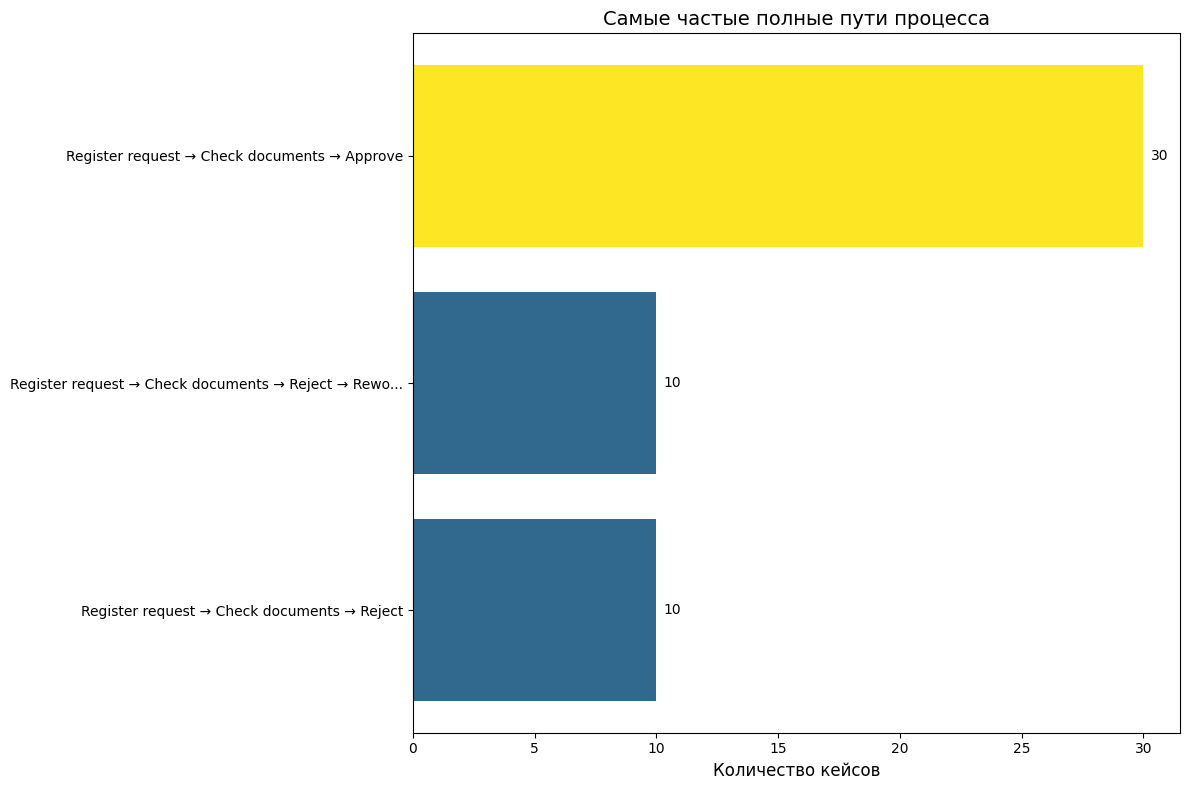

In [39]:
# ====================================================
# ШАГ 12: ВИЗУАЛИЗАЦИЯ 6 - САМЫЕ ЧАСТЫЕ ПУТИ
# ====================================================

paths = []
for case_id, group in event_log.groupby('case:concept:name'):
    path = ' → '.join(group['concept:name'].tolist())
    paths.append(path)

path_counts = Counter(paths).most_common(8)
path_names = [p[:50] + '...' if len(p) > 50 else p for p, _ in path_counts]
path_freq = [c for _, c in path_counts]

plt.figure(figsize=(12, 8))
colors = plt.cm.viridis([f/max(path_freq) for f in path_freq])
bars = plt.barh(path_names, path_freq, color=colors)
plt.xlabel('Количество кейсов', fontsize=12)
plt.title('Самые частые полные пути процесса', fontsize=14)
plt.gca().invert_yaxis()

for bar, freq in zip(bars, path_freq):
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             str(freq), ha='left', va='center')

plt.tight_layout()
plt.show()

In [41]:
# ====================================================
# ШАГ 13: ИТОГОВЫЙ ОТЧЁТ
# ====================================================

print("\n" + "="*70)
print("ИТОГОВЫЙ ОТЧЁТ ПО ПРОЕКТУ PROCESS MINING")
print("="*70)

print(f"""
📊 МЕТРИКИ ПРОЦЕССА:
─────────────────────────────────────────────────
• Кейсов: {len(durations)}
• Событий: {len(event_log)}
• Активностей: {len(all_activities)}
• Вариантов процесса: {len(variants)}
• Переходов: {len(dfg)}

⏱️ ВРЕМЕННЫЕ МЕТРИКИ:
─────────────────────────────────────────────────
• Средняя длительность: {avg_duration:.1f} ч ({avg_duration/24:.1f} дн.)
• Минимальная: {min_duration:.1f} ч
• Максимальная: {max_duration:.1f} ч

🎯 РЕЗУЛЬТАТИВНОСТЬ:
─────────────────────────────────────────────────
• Успешных (Approve): {len(success_cases)} ({len(success_cases)/len(durations)*100:.1f}%)
• Отказов (Reject): {len(fail_cases)} ({len(fail_cases)/len(durations)*100:.1f}%)

🔧 РЕКОМЕНДАЦИИ:
─────────────────────────────────────────────────
1. Стандартизировать основной путь (30 кейсов, 60%)
2. Сократить время перехода "Check documents → Reject"
3. Внедрить мониторинг аномальных длительностей (> {avg_duration*2:.0f} ч)
4. Автоматизировать повторяющиеся проверки
""")



ИТОГОВЫЙ ОТЧЁТ ПО ПРОЕКТУ PROCESS MINING

📊 МЕТРИКИ ПРОЦЕССА:
─────────────────────────────────────────────────
• Кейсов: 50
• Событий: 170
• Активностей: 5
• Вариантов процесса: 3
• Переходов: 5

⏱️ ВРЕМЕННЫЕ МЕТРИКИ:
─────────────────────────────────────────────────
• Средняя длительность: 57.6 ч (2.4 дн.)
• Минимальная: 48.0 ч
• Максимальная: 96.0 ч

🎯 РЕЗУЛЬТАТИВНОСТЬ:
─────────────────────────────────────────────────
• Успешных (Approve): 40 (80.0%)
• Отказов (Reject): 10 (20.0%)

🔧 РЕКОМЕНДАЦИИ:
─────────────────────────────────────────────────
1. Стандартизировать основной путь (30 кейсов, 60%)
2. Сократить время перехода "Check documents → Reject"
3. Внедрить мониторинг аномальных длительностей (> 115 ч)
4. Автоматизировать повторяющиеся проверки

